# Baseline Drivetrain Failure Models

Five baseline classifiers are compared for predicting `failure` (0 = normal, 1 = fault). Recall for fault records is the primary metric because missed failures are more costly than unnecessary inspections.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

sns.set_theme(style='whitegrid', context='notebook')
RANDOM_STATE = 42
metric_of_choice = 'recall'  # choose one of: accuracy, precision, recall, f1
if metric_of_choice not in {'accuracy', 'precision', 'recall', 'f1'}:
    raise ValueError('metric_of_choice must be accuracy, precision, recall, or f1')

ROOT = Path.cwd().parent
if not (ROOT / 'data' / 'raw' / 'wind_turbine_detection.csv').exists():
    ROOT = Path.cwd() / 'PROJECT 1'
df = pd.read_csv(ROOT / 'data' / 'raw' / 'wind_turbine_detection.csv')

# Baseline uses numeric measurements only; identifiers and raw timestamps are intentionally excluded.
target = 'failure'
predictor_columns = [column for column in df.select_dtypes(include='number').columns if column != target]
X = df[predictor_columns]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.20, stratify=y, random_state=RANDOM_STATE)
positive_weight = (y_train == 0).sum() / (y_train == 1).sum()
display(Markdown(f'**Predictors:** {len(predictor_columns)} numeric fields. `timestamp` and `turbine_id` are excluded in this baseline; add validated time and turbine features later.\n\n**Split:** {len(X_train):,} train / {len(X_test):,} test records; training fault prevalence = {y_train.mean():.2%}.'))

**Predictors:** 32 numeric fields. `timestamp` and `turbine_id` are excluded in this baseline; add validated time and turbine features later.

**Split:** 105,408 train / 26,352 test records; training fault prevalence = 3.00%.

In [2]:
import sys
print(sys.executable)
print(sys.version)


/Users/sanniadedokun/Desktop/DBA/.venv/bin/python
3.12.14 (main, Aug 12 2026, 13:57:54) [Clang 21.0.0 (clang-2100.1.1.101)]


In [3]:
def model_performance_classification(classifier, predictors, target):
    """Return accuracy, recall, precision, and F1 for a fitted binary classifier."""
    predictions = classifier.predict(predictors)
    return pd.DataFrame([{
        'accuracy': accuracy_score(target, predictions),
        'recall': recall_score(target, predictions, pos_label=1, zero_division=0),
        'precision': precision_score(target, predictions, pos_label=1, zero_division=0),
        'f1': f1_score(target, predictions, pos_label=1, zero_division=0),
    }])

def plot_confusion_matrix(classifier, predictors, target, model_name='Classifier'):
    """Plot count and row-percentage confusion matrix; class 1 is the positive fault class."""
    predictions = classifier.predict(predictors)
    matrix = confusion_matrix(target, predictions, labels=[0, 1])
    row_percentages = matrix / matrix.sum(axis=1, keepdims=True) * 100
    labels = np.array([[f'{count:,}\n({percentage:.1f}%)' for count, percentage in zip(count_row, pct_row)] for count_row, pct_row in zip(matrix, row_percentages)])
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    sns.heatmap(matrix, annot=labels, fmt='', cmap='Blues', cbar=False, square=True, ax=ax, xticklabels=['Predicted normal (0)', 'Predicted fault (1)'], yticklabels=['Actual normal (0)', 'Actual fault (1)'])
    ax.set(title=f'{model_name}: Confusion Matrix', xlabel='Predicted class', ylabel='Actual class')
    plt.tight_layout(); plt.show(); plt.close(fig)
    return pd.DataFrame(matrix, index=['actual_normal_0', 'actual_fault_1'], columns=['predicted_normal_0', 'predicted_fault_1'])

display(Markdown('Reusable `model_performance_classification` and `plot_confusion_matrix` functions are defined. Percentages in each confusion-matrix row are relative to the actual class, making fault recall visible in the `actual_fault_1` row.'))

Reusable `model_performance_classification` and `plot_confusion_matrix` functions are defined. Percentages in each confusion-matrix row are relative to the actual class, making fault recall visible in the `actual_fault_1` row.

In [4]:
# Shared preprocessing and five baseline models
tree_preprocess = Pipeline([('imputer', SimpleImputer(strategy='median'))])
ann_preprocess = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])

models = {
    'Decision Tree': Pipeline([('preprocess', tree_preprocess), ('model', DecisionTreeClassifier(class_weight='balanced', min_samples_leaf=10, random_state=RANDOM_STATE))]),
    'Random Forest': Pipeline([('preprocess', tree_preprocess), ('model', RandomForestClassifier(n_estimators=150, class_weight='balanced_subsample', n_jobs=-1, random_state=RANDOM_STATE))]),
    'Gradient Boosting': Pipeline([('preprocess', tree_preprocess), ('model', GradientBoostingClassifier(n_estimators=150, learning_rate=.08, max_depth=3, random_state=RANDOM_STATE))]),
    'XGBoost': Pipeline([('preprocess', tree_preprocess), ('model', XGBClassifier(n_estimators=200, max_depth=4, learning_rate=.08, subsample=.8, colsample_bytree=.8, scale_pos_weight=positive_weight, eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1))]),
    'ANN': Pipeline([('preprocess', ann_preprocess), ('model', MLPClassifier(hidden_layer_sizes=(64, 32), early_stopping=True, max_iter=150, random_state=RANDOM_STATE))]),
}

results, fitted_models = [], {}
for name, model in models.items():
    model.fit(X_train, y_train)
    fitted_models[name] = model
    result = model_performance_classification(model, X_test, y_test)
    result.insert(0, 'model', name)
    results.append(result)

performance = pd.concat(results, ignore_index=True).sort_values(metric_of_choice, ascending=False).reset_index(drop=True)
display(Markdown(f'## Baseline model performance (ranked by **{metric_of_choice}** for fault class `1`)'))
display(performance.style.format({'accuracy': '{:.3f}', 'precision': '{:.3f}', 'recall': '{:.3f}', 'f1': '{:.3f}'}).highlight_max(subset=[metric_of_choice], color='#c6efce'))
best_model = performance.iloc[0]
display(Markdown(f'**Primary-metric result:** `{best_model.model}` has the highest test **{metric_of_choice}** of **{best_model[metric_of_choice]:.3f}**. Recall is prioritised because it measures the share of actual faults detected.'))

## Baseline model performance (ranked by **recall** for fault class `1`)

,model,accuracy,recall,precision,f1
0,XGBoost,0.991,0.989,0.766,0.863
1,Decision Tree,0.992,0.970,0.801,0.877
2,Random Forest,0.995,0.932,0.917,0.924
3,Gradient Boosting,0.994,0.895,0.894,0.895
4,ANN,0.993,0.875,0.883,0.879


**Primary-metric result:** `XGBoost` has the highest test **recall** of **0.989**. Recall is prioritised because it measures the share of actual faults detected.

## Confusion matrices (positive class: fault = 1)

### Decision Tree

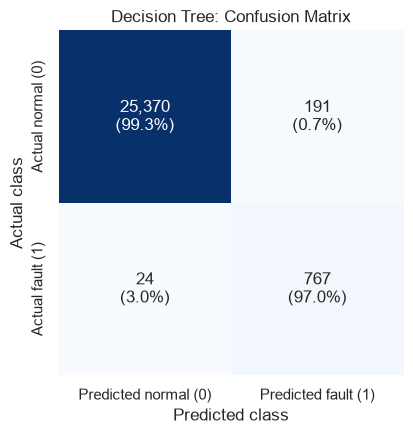

,predicted_normal_0,predicted_fault_1
actual_normal_0,25370,191
actual_fault_1,24,767


### Random Forest

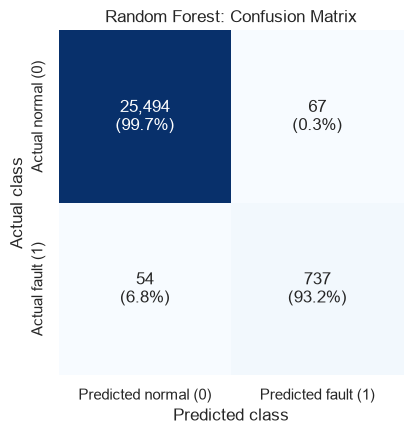

,predicted_normal_0,predicted_fault_1
actual_normal_0,25494,67
actual_fault_1,54,737


### Gradient Boosting

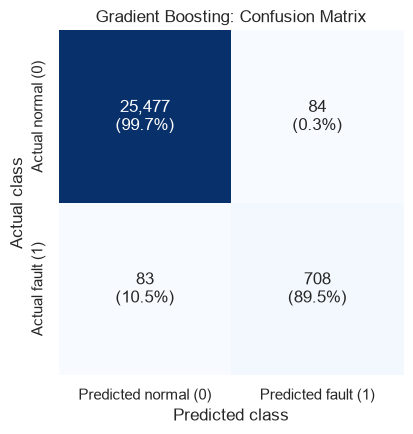

,predicted_normal_0,predicted_fault_1
actual_normal_0,25477,84
actual_fault_1,83,708


### XGBoost

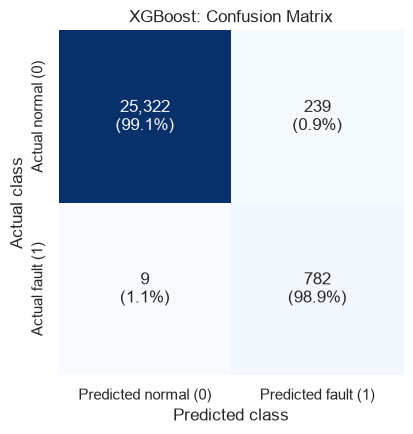

,predicted_normal_0,predicted_fault_1
actual_normal_0,25322,239
actual_fault_1,9,782


### ANN

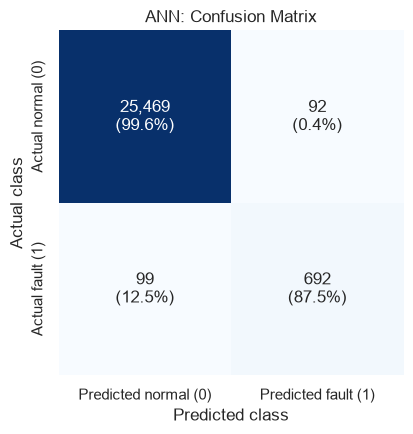

,predicted_normal_0,predicted_fault_1
actual_normal_0,25469,92
actual_fault_1,99,692


In [5]:
# Confusion matrices: count and within-actual-class percentage for every baseline
display(Markdown('## Confusion matrices (positive class: fault = 1)'))
confusion_tables = {}
for name, model in fitted_models.items():
    display(Markdown(f'### {name}'))
    confusion_tables[name] = plot_confusion_matrix(model, X_test, y_test, model_name=name)
    display(confusion_tables[name])

In [6]:
import xgboost
print(xgboost.__version__)

3.4.1


In [7]:
import pandas
import numpy
import sklearn
import tensorflow
import keras
import seaborn
import matplotlib

print("All imports working!")


All imports working!


In [8]:
import xgboost
print(xgboost.__version__)



3.4.1


In [9]:
import pandas
import numpy
import sklearn
import tensorflow
import keras
import seaborn
import matplotlib

print("All imports working!")

All imports working!
